# Tier 18: redundancy

Plan 032. Redundancy as topology multiplicity plus Tier 15 hardware, and failure cases as extra flight points of
the one sizing problem (no loops):

| Piece | Model |
|---|---|
| Lanes | N lane motors per rotor (each 1/N of the torque) on a combining gearbox input: equal speed, torques add |
| Buses | B cross-strapped buses (lumped junction, `Bus.count`), B - 1 normally open ties: `ProtectionUnit` + 2 m `Cable` at 125 % of one bus's source rating |
| Strings | the pack split into S strings, each behind a `ProtectionUnit` at 125 % of the string's discharge rating |
| Lane out | N - 1 lanes carry the rotor torque, on both rotors (symmetric, conservative) |
| Bus out | the failed bus's N / B lanes are lost; its sources feed the others through a tie (tie current, loss in the bus demand) |
| String out | S - 1 strings at the pack SOC: capacity, current rating, conductance and thermal mass x (S - 1) / S |

The switch `HaloAssumptions.redundancy` is **off by default**; the reference (900 kg, 210 kt, AeroBuildup,
thermal on, 14,037 lb) is unchanged. Failure hovers: 60 s at MTOM from the SOC floor (0.30) to the emergency
floor (0.10), thermal history from the end of the take-off hover.

In [1]:
import sys
import time
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.core.ports import MechanicalPortValue
from aircraft_closure.core.topology import connection_residuals
from aircraft_closure.performance.flight_point import FlightCondition
from aircraft_closure.powertrain.components.battery_ecm import EquivalentCircuitBattery
from aircraft_closure.powertrain.components.thermal import LumpedThermalModel
from aircraft_closure.powertrain.redundancy import battery_with_strings, degraded_state
from aircraft_closure.thermal.heat import thermal_parameters
from examples.halo_sizing import HaloAssumptions, assumptions_tier18, build_halo_aircraft, solve_halo_sizing
from tests.integration.test_halo_thermal import numeric_design
from tests.performance.test_flight_point_redundancy import (redundant_aircraft, solve, string_contactor, tie_cable,
                                                            tie_contactor)

check_log = []


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow, violet = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8a5cd6"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})

## 1. Architecture in the topology: combiners, bus copies, ties and strings

A combiner joins N lane motors to one gearbox input (speed equal, N x lane torque = gearbox torque); the pack is
split into string contactors the same way. All ones builds the plain topology.

In [2]:
plain = build_halo_aircraft(numeric_design())
ones = build_halo_aircraft(numeric_design(), assumptions=HaloAssumptions(
    redundancy=True, count_lanes_motor=1, count_buses=1, count_strings_battery=1))
redundant = build_halo_aircraft(replace(numeric_design(), torque_peak_motor_Nm=200.0), assumptions=assumptions_tier18)
t = redundant.powertrain.topology
print(f"{'instance':<22}{'plain':>7}{'2/2/2':>7}")
for name, instance in t.instances.items():
    count_plain = plain.powertrain.topology.instances[name].count if name in plain.powertrain.topology.instances else 0
    print(f"{name:<22}{count_plain:7d}{instance.count:7d}")
print("bus copies:", t.buses["bus"].count, "| combined connections:",
      [(c.source, c.target) for c in t.connections if c.combine])
check("all ones builds the plain topology", plain.powertrain.topology.connections == ones.powertrain.topology.connections
      and {n: i.count for n, i in plain.powertrain.topology.instances.items()}
      == {n: i.count for n, i in ones.powertrain.topology.instances.items()})
from aircraft_closure.core.topology import Topology
from aircraft_closure.core.ports import PortSpec, Domain, Direction
toy = Topology()
toy.add("motor", object(), (PortSpec("shaft", Domain.MECHANICAL, Direction.OUT),), count=4)
toy.add("gearbox", object(), (PortSpec("shaft", Domain.MECHANICAL, Direction.IN),), count=2)
toy.connect("motor.shaft", "gearbox.shaft", combine=True)
r = {x.label: x.value for x in connection_residuals(toy, {"motor.shaft": MechanicalPortValue(400.0, 150.0),
                                                           "gearbox.shaft": MechanicalPortValue(400.0, 300.0)})}
check("combiner: two lanes of 150 N.m balance a 300 N.m gearbox input", all(v == 0 for v in r.values()))

instance                plain  2/2/2
turboshaft                  2      2
generator                   2      2
battery                     1      1
motor                       2      4
gearbox                     2      2
propulsor                   2      2
generator_gearbox           2      2
protection_string           0      2
protection_bus_tie          0      1
cable_bus_tie               0      1
bus copies: 2 | combined connections: [('battery.electrical', 'protection_string.input'), ('motor.shaft', 'gearbox.shaft_in')]
PASS  all ones builds the plain topology
PASS  combiner: two lanes of 150 N.m balance a 300 N.m gearbox input


## 2. Multiplicity masses

With the torque-density machine mass (linear in torque) N lanes at 1/N of the torque weigh one machine, so lanes
cost mass only through the failure cases (and, with the Tier 15 layer, per-lane feeder overheads). Ties and
string contactors are the components times their counts.

In [3]:
def masses(aircraft):
    return {i.instance_name: float(i.mass_properties.mass) for i in aircraft.powertrain.get_instance_mass_properties()}

m_plain, m_red = masses(plain), masses(redundant)
print(f"motors: plain {m_plain['motor']:.1f} kg (2 x 400 N.m), 2 lanes x 2 rotors at 200 N.m {m_red['motor']:.1f} kg")
# The smooth maximum in the mass model adds at most 2 kg x ln 2 per machine, so 4 lanes vs 2 machines differ by
# at most 4 x 1.39 kg.
check("two half-torque lanes weigh one machine (within the softmax smoothing)",
      abs(m_red["motor"] - m_plain["motor"]) <= 4 * 2.0 * np.log(2))
for name in ("protection_string", "protection_bus_tie", "cable_bus_tie"):
    inst = t.instances[name]
    check(f"{name}: installed mass = count x component mass",
          abs(m_red[name] - inst.count * float(inst.component.get_mass())) < 1e-9)
    print(f"  {name}: {inst.count} x {float(inst.component.get_mass()):.2f} kg, rated "
          f"{float(inst.component.max_current_A):.0f} A")
with_layer = masses(build_halo_aircraft(replace(numeric_design(), torque_peak_motor_Nm=400.0 / 2),
                                        assumptions=replace(assumptions_tier18, electrical_layer=True)))
plain_layer = masses(build_halo_aircraft(numeric_design(), assumptions=HaloAssumptions(electrical_layer=True)))
over_kg = sum(with_layer[n] - plain_layer[n] for n in ("cable_motor", "protection_motor", "inverter_motor"))
print(f"with the Tier 15 layer, lane feeders (inverters, cables, contactors) add {over_kg:.1f} kg at the same torque")
check("with the layer, per-lane feeders cost mass (fixed contactor and insulation terms)", over_kg > 0)

motors: plain 138.8 kg (2 x 400 N.m), 2 lanes x 2 rotors at 200 N.m 141.3 kg
PASS  two half-torque lanes weigh one machine (within the softmax smoothing)
PASS  protection_string: installed mass = count x component mass
  protection_string: 2 x 1.86 kg, rated 560 A
PASS  protection_bus_tie: installed mass = count x component mass
  protection_bus_tie: 1 x 7.71 kg, rated 2811 A
PASS  cable_bus_tie: installed mass = count x component mass
  cable_bus_tie: 1 x 12.50 kg, rated 2811 A
with the Tier 15 layer, lane feeders (inverters, cables, contactors) add 1.7 kg at the same torque
PASS  with the layer, per-lane feeders cost mass (fixed contactor and insulation terms)


## 3. Degraded flight points (four-rotor reference)

Lane out: the surviving lane carries the gearbox torque; bus out: the tie carries the failed bus's share; string
out: the pack's limits and sag are those of the remaining strings.

 lanes  lane kW  motors kW  lane-out lane kW  lane-out motors kW
     1     61.2      254.9               nan                 nan
     2     30.6      254.9              61.2               255.0
     3     20.4      254.9              30.6               254.9
     4     15.3      254.9              20.4               254.9
PASS  healthy lanes draw exactly one machine's power
PASS  lane out: each surviving lane carries ~N/(N-1) of its healthy share
PASS  lane out, N = 2: copper x N/(N-1), spinning loss x (N-1)/N
PASS  lane out, N = 3: copper x N/(N-1), spinning loss x (N-1)/N
PASS  lane out, N = 4: copper x N/(N-1), spinning loss x (N-1)/N
PASS  bus out: tie current = motor demand / (2 x bus voltage)
PASS  bus out: tie loss = I^2 (R_contactor + R_cable)
bus out: 1 lane per rotor, tie 160 A, loss 30 W
PASS  string out: half the strings, half the current rating and capacity
PASS  string out: thermal time constant unchanged (C x 1/2, R x 2)


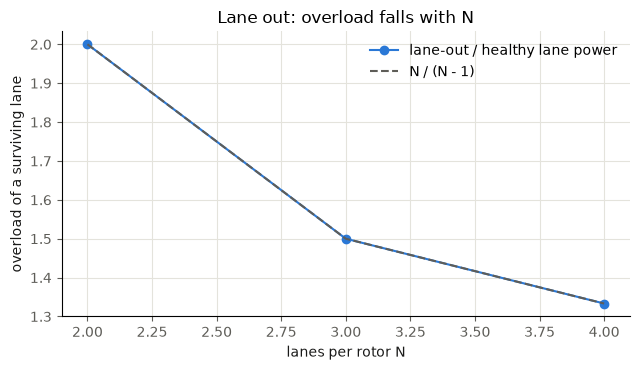

In [4]:
rows = []
for lanes_total in (1, 2, 3, 4):
    aircraft = redundant_aircraft(count_lanes=lanes_total)
    healthy, s0 = solve(aircraft)
    row = dict(lanes=lanes_total, healthy_lane_kW=float(s0.value(healthy.speed_motor_rad_s * healthy.torque_motor_Nm)) / 1e3,
               healthy_motors_kW=float(s0.value(healthy.power_electric_motors_W)) / 1e3)
    if lanes_total > 1:
        out, s1 = solve(aircraft, FlightCondition(mode="hover", altitude_m=0.0, label="lane out",
                                                  active_lane_count=lanes_total - 1))
        row.update(out_lane_kW=float(s1.value(out.speed_motor_rad_s * out.torque_motor_Nm)) / 1e3,
                   out_motors_kW=float(s1.value(out.power_electric_motors_W)) / 1e3)
    rows.append(row)
print(f"{'lanes':>6}{'lane kW':>9}{'motors kW':>11}{'lane-out lane kW':>18}{'lane-out motors kW':>20}")
for r in rows:
    print(f"{r['lanes']:6d}{r['healthy_lane_kW']:9.1f}{r['healthy_motors_kW']:11.1f}"
          f"{r.get('out_lane_kW', float('nan')):18.1f}{r.get('out_motors_kW', float('nan')):20.1f}")
check("healthy lanes draw exactly one machine's power", all(abs(r["healthy_motors_kW"] / rows[0]["healthy_motors_kW"] - 1)
                                                         < 1e-6 for r in rows))
check("lane out: each surviving lane carries ~N/(N-1) of its healthy share",
      all(abs(r["out_lane_kW"] / r["healthy_lane_kW"] / (r["lanes"] / (r["lanes"] - 1)) - 1) < 0.03 for r in rows[1:]))
# Loss split at equal speed and rotor torque (McDonald, rubber lanes): the active lanes' copper loss C3 Q^2 rises by
# N / (N - 1), while the speed-dependent loss (C0 + C1 w + C2 w^3) falls by (N - 1) / N because the failed lane is
# declutched (a freewheel per lane, assumed) and no longer spins. Net loss can therefore fall slightly (table).
from aircraft_closure.powertrain.components.motor import Motor
from tests.performance.test_flight_point_redundancy import lane_of
speed_rad_s, torque_Nm = 400.0, 300.0
for lanes_total in (2, 3, 4):
    lane = lane_of(Motor(), lanes_total)
    c = lane.loss_model.coefficients()
    copper = lambda active: active * c.torque_W_Nm2 * (torque_Nm / active)**2
    spinning = lambda active: active * (c.constant_W + c.linear_W_s_rad * speed_rad_s + c.cubic_W_s3_rad3 * speed_rad_s**3)
    total = lambda active: active * lane.loss_model.evaluate(speed_rad_s, torque_Nm / active, 800.0)
    ok = (abs(copper(lanes_total - 1) / copper(lanes_total) - lanes_total / (lanes_total - 1)) < 1e-12
          and abs(spinning(lanes_total - 1) / spinning(lanes_total) - (lanes_total - 1) / lanes_total) < 1e-12
          and abs(total(lanes_total - 1) - copper(lanes_total - 1) - spinning(lanes_total - 1)) < 1e-9)
    check(f"lane out, N = {lanes_total}: copper x N/(N-1), spinning loss x (N-1)/N", ok)

aircraft = redundant_aircraft(count_lanes=2, count_buses=2)
bus, s = solve(aircraft, FlightCondition(mode="hover", altitude_m=0.0, label="bus out", count_buses_failed=1))
current_A = float(s.value(bus.redundancy.current_tie_A))
check("bus out: tie current = motor demand / (2 x bus voltage)",
      abs(current_A - float(s.value(bus.power_electric_motors_W / (2 * bus.battery.voltage_V)))) < 1e-6)
loss_W = float(s.value(bus.redundancy.power_loss_tie_W))
check("bus out: tie loss = I^2 (R_contactor + R_cable)",
      abs(loss_W - current_A**2 * (tie_contactor.resistance_ohm() + tie_cable.resistance_ohm())) < 1e-6)
print(f"bus out: {bus.redundancy.count_lanes_active} lane per rotor, tie {current_A:.0f} A, loss {loss_W:.0f} W")

pack = EquivalentCircuitBattery(count_parallel=20.0, thermal_model=LumpedThermalModel(1000.0, 60.0, 25.0))
half = battery_with_strings(pack, 0.5)
check("string out: half the strings, half the current rating and capacity",
      abs(half.get_limits().max_discharge_current_A / pack.get_limits().max_discharge_current_A - 0.5) < 1e-12
      and abs(half.energy_capacity_J / pack.energy_capacity_J - 0.5) < 1e-12)
p_full, p_half = thermal_parameters(pack), thermal_parameters(half)
check("string out: thermal time constant unchanged (C x 1/2, R x 2)",
      abs(p_full.capacity_J_K * p_full.resistance_K_W - p_half.capacity_J_K * p_half.resistance_K_W) < 1e-9)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
n = [r["lanes"] for r in rows[1:]]
ax.plot(n, [r["out_lane_kW"] / r["healthy_lane_kW"] for r in rows[1:]], "o-", color=blue, label="lane-out / healthy lane power")
ax.plot(n, [k / (k - 1) for k in n], "--", color=ink_muted, label="N / (N - 1)")
ax.set(xlabel="lanes per rotor N", ylabel="overload of a surviving lane", title="Lane out: overload falls with N")
ax.legend(frameon=False)
plt.tight_layout()

## 4. The Halo: redundancy off and on (AeroBuildup, thermal on, 900 kg, 210 kt)

Every variant starts from the reference solution (lane torques scaled to keep the torque per rotor); with battery
strings, a failed solve is restarted from the same problem without the strings (`staged_start`, a starting point
only). The double failures start from the 2/2/2 solution. Each is one
coupled solve with its failure hovers as extra points. With one lane per rotor on each bus the bus-out hover covers
the lane out (same lanes lost, plus the tie), so the lane-out point is not repeated.

In [5]:
t0 = time.time()
reference = solve_halo_sizing()
print(f"reference: {reference.mass_takeoff_kg / u.lbm:,.0f} lb ({time.time() - t0:.0f} s)")
check("reference unchanged with defaults: 14,037 lb", abs(reference.mass_takeoff_kg / u.lbm - 14037) < 10)
base = HaloAssumptions(redundancy=True, count_lanes_motor=1, count_buses=1, count_strings_battery=1,
                       failure_lane_out=False, failure_bus_out=False, failure_string_out=False)
variants = {
    "1 lane, no cases": base,
    "2 lanes": replace(base, count_lanes_motor=2, failure_lane_out=True),
    "3 lanes": replace(base, count_lanes_motor=3, failure_lane_out=True),
    "4 lanes": replace(base, count_lanes_motor=4, failure_lane_out=True),
    "2 lanes, 2 buses": replace(base, count_lanes_motor=2, count_buses=2, failure_lane_out=True, failure_bus_out=True),
    "2 strings": replace(base, count_strings_battery=2, failure_string_out=True),
    "2/2/2 (assumptions_tier18)": assumptions_tier18,
    "2/2/2 + double failures": replace(assumptions_tier18, failure_string_out_engine_out=True,
                                       failure_lane_out_engine_out=True),
}
results = {}
for name, assumptions in variants.items():
    t0 = time.time()
    # The double failures start from the 2/2/2 solution (solved just before); the rest from the reference.
    start = results["2/2/2 (assumptions_tier18)"] if "double" in name else reference
    try:
        results[name] = solve_halo_sizing(assumptions=assumptions, initial=start, staged_start="double" not in name)
        print(f"{name:<30}{results[name].mass_takeoff_kg / u.lbm:8,.0f} lb ({time.time() - t0:.0f} s)")
    except RuntimeError as error:
        results[name] = None
        print(f"{name:<30} did not solve ({time.time() - t0:.0f} s): {str(error).splitlines()[-1][:90]}")
check("one lane without cases is the reference", abs(results["1 lane, no cases"].mass_takeoff_kg
                                                    / reference.mass_takeoff_kg - 1) < 1e-5)
check("every single-failure variant closes with all margins",
      all(results[n] is not None and results[n].min_margin > -1e-6 for n in list(variants)[:7]))

CasADi - 2026-10-04 16:20:07 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:20:07 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


reference: 14,037 lb (207 s)
PASS  reference unchanged with defaults: 14,037 lb


1 lane, no cases                14,037 lb (89 s)


2 lanes                         14,201 lb (125 s)


...

CasADi - 2026-10-04 16:39:47 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 923, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 16:39:48 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 923, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 16:39:48 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 923, col 0).") [.../casadi/core/oracle_function.cpp:408]


2/2/2 (assumptions_tier18)      14,342 lb (472 s)


2/2/2 + double failures        did not solve (406 s): Solver failed. You may use opti.debug.value to investigate the latest values of variables.


PASS  one lane without cases is the reference
PASS  every single-failure variant closes with all margins


architecture                    MTOM kg      lb   d kg  lane kW lanes kW      motor    gearbox    battery heat_excha protection protection cable_bus_
reference                          6367   14037      0      570      570      115.9      356.5      412.3      133.5        0.0        0.0        0.0
1 lane, no cases                   6367   14037     -0      570      570      115.9      356.5      412.3      133.5        0.0        0.0        0.0
2 lanes                            6441   14201     75      333      666      155.7      355.4      423.9      131.5        0.0        0.0        0.0
3 lanes                            6380   14066     13      190      570      120.2      358.3      414.4      133.1        0.0        0.0        0.0
4 lanes                            6401   14112     34      145      580      138.0      353.2      417.4      130.1        0.0        0.0        0.0
2 lanes, 2 buses                   6493   14314    126      335      671      157.0      358.7      

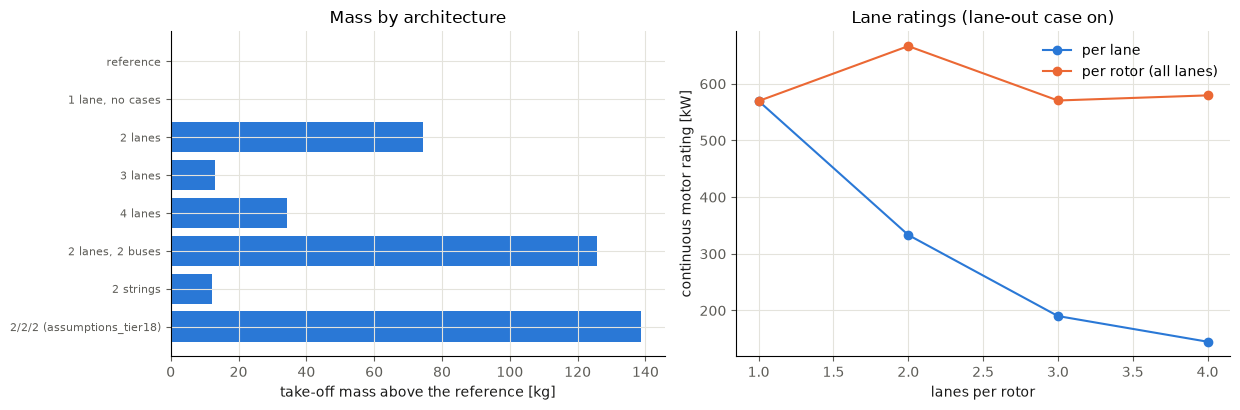

In [6]:
names = ["reference"] + [n for n in variants if results[n] is not None]
res = {"reference": reference, **{n: results[n] for n in names[1:]}}
items = ("motor", "gearbox", "battery", "heat_exchanger", "protection_string", "protection_bus_tie", "cable_bus_tie")
print(f"{'architecture':<30}{'MTOM kg':>9}{'lb':>8}{'d kg':>7}{'lane kW':>9}{'lanes kW':>9}" + "".join(f"{i[:10]:>11}" for i in items))
for n in names:
    r = res[n]
    m = dict(r.powertrain_masses_kg)
    print(f"{n:<30}{r.mass_takeoff_kg:9.0f}{r.mass_takeoff_kg / u.lbm:8.0f}{r.mass_takeoff_kg - reference.mass_takeoff_kg:7.0f}"
          f"{r.power_rated_motor_W / 1e3:9.0f}{r.count_lanes_motor * r.power_rated_motor_W / 1e3:9.0f}"
          + "".join(f"{m.get(i, 0.0):11.1f}" for i in items))
lane_names = ["reference", "2 lanes", "3 lanes", "4 lanes"]
lane_rated = [res[n].power_rated_motor_W for n in lane_names if n in res]
check("more lanes: lower per-lane rating", all(a > b for a, b in zip(lane_rated, lane_rated[1:])))
check("lanes with a lane-out case: heavier than the single-lane reference",
      all(res[n].mass_takeoff_kg > reference.mass_takeoff_kg for n in lane_names[1:] if n in res))
check("the sensible set (2/2/2) is heavier than the reference",
      res["2/2/2 (assumptions_tier18)"].mass_takeoff_kg > reference.mass_takeoff_kg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
y = np.arange(len(names))
ax1.barh(y, [res[n].mass_takeoff_kg - reference.mass_takeoff_kg for n in names], color=blue)
ax1.set_yticks(y, names, fontsize=8)
ax1.invert_yaxis()
ax1.set(xlabel="take-off mass above the reference [kg]", title="Mass by architecture")
ax2.plot([1, 2, 3, 4][:len(lane_rated)], np.array(lane_rated) / 1e3, "o-", color=blue, label="per lane")
ax2.plot([1, 2, 3, 4][:len(lane_rated)], np.array(lane_rated) * np.arange(1, len(lane_rated) + 1) / 1e3, "o-",
         color=orange, label="per rotor (all lanes)")
ax2.set(xlabel="lanes per rotor", ylabel="continuous motor rating [kW]", title="Lane ratings (lane-out case on)")
ax2.legend(frameon=False)
plt.tight_layout()

failure case                   lanes  str  eng  SOC end  Q/Qmax  T_mot C  I_bat A  I_tie A  min margin  binding
2/2/2 (assumptions_tier18)
  bus-out hover                    1    2    2    0.262    0.75    150.0      556      964     -0.0000  motor temperature_C
  string-out hover                 2    1    2    0.215    0.39    113.3      238        0      0.1224  
PASS  every failure case closes (margins >= 0, SOC above the emergency floor)
PASS  bus out (covers the lane out): the surviving lane is held by its temperature limit (thermal on)
PASS  bus out: the tie carries current and one lane per rotor survives
PASS  heat exchanger covers every failure point


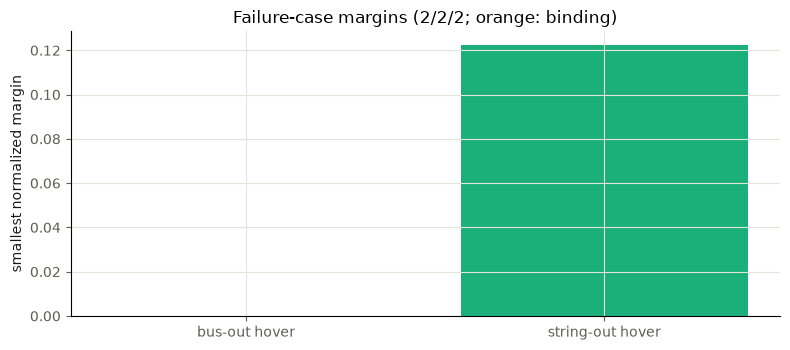

In [7]:
sized = res["2/2/2 (assumptions_tier18)"]
print(f"{'failure case':<30}{'lanes':>6}{'str':>5}{'eng':>5}{'SOC end':>9}{'Q/Qmax':>8}{'T_mot C':>9}{'I_bat A':>9}"
      f"{'I_tie A':>9}{'min margin':>12}  binding")
for n in ("2/2/2 (assumptions_tier18)", "2/2/2 + double failures"):
    if res.get(n) is None:
        continue
    print(n)
    for c in res[n].failure_cases:
        print(f"  {c['label']:<28}{c['count_lanes_active']:6d}{c['count_strings_active']:5d}{c['count_generators_active']:5d}"
              f"{c['soc_end']:9.3f}{c['torque_lane_to_max']:8.2f}{c['temperature_end_motor_C']:9.1f}"
              f"{c['current_battery_max_A']:9.0f}{c['current_tie_A']:9.0f}{c['min_margin']:12.4f}  "
              + ", ".join(b.split(": ")[-1] for b in c["binding"]))
cases = {c["label"]: c for c in sized.failure_cases}
check("every failure case closes (margins >= 0, SOC above the emergency floor)",
      all(c["min_margin"] > -1e-6 and c["soc_end"] >= 0.1 - 1e-6 for c in cases.values()))
check("bus out (covers the lane out): the surviving lane is held by its temperature limit (thermal on)",
      any("motor temperature_C" in b for b in cases["bus-out hover"]["binding"]))
check("bus out: the tie carries current and one lane per rotor survives",
      cases["bus-out hover"]["current_tie_A"] > 0 and cases["bus-out hover"]["count_lanes_active"] == 1)
check("heat exchanger covers every failure point", max(r["power_heat_equivalent_W"] for r in sized.thermal_trace)
      <= sized.heat_exchanger["power_rated_W"] * (1 + 1e-6))

fig, ax = plt.subplots(figsize=(8, 3.6))
labels = [c["label"] for c in sized.failure_cases]
ax.bar(labels, [c["min_margin"] for c in sized.failure_cases], color=[orange if c["binding"] else aqua
                                                                     for c in sized.failure_cases])
ax.set(ylabel="smallest normalized margin", title="Failure-case margins (2/2/2; orange: binding)")
plt.tight_layout()

## 5. Summary

In [8]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

26 / 26 notebook checks passed


In [9]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 535 tests in 2294.905s

OK (skipped=1)
